# File 5 — DenseNet121 Transfer Learning

**Chiến thuật:** Huấn luyện 2 giai đoạn (Two-phase Training), giống ResNet50/MobileNetV2:
- **Phase 1 — Feature Extraction:** Đóng băng toàn bộ backbone, chỉ train Classifier Head.
- **Phase 2 — Fine-tuning:** Mở băng **Dense Block 4** (block cuối) + lớp BN cuối cùng, train tiếp với LR cực nhỏ.

**Lưu ý quan trọng:** DenseNet121 dùng `preprocess_input` chuẩn **Torch** (khác hẳn Caffe của ResNet50 và [-1,1] của MobileNetV2):
scale pixel về [0,1] rồi chuẩn hóa theo mean/std của ImageNet (`mean=[0.485,0.456,0.406]`, `std=[0.229,0.224,0.225]`).

## 1. Cấu hình & Hằng số

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_DIR = "/kaggle/input/notebooks/ngchypnguyn/ti-n-x-l-d-li-u/final_dataset"
os.makedirs("/kaggle/working/results", exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 50


FINE_TUNE_PREFIX = ("conv4_", "conv5_")
FINE_TUNE_EXTRA_LAYERS = ["bn"]   # lớp BN cuối cùng, đứng ngay trước GAP

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Load dữ liệu

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    image_size=(256, 256),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "val"),
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    image_size=(256, 256),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    image_size=(256, 256),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_file_paths = test_ds.file_paths  # lấy ngay tại đây, TRƯỚC khi .map() — tránh mất thuộc tính này

print(f"Batch train : {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Batch val   : {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Batch test  : {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 4069 files belonging to 2 classes.


I0000 00:00:1784976764.945196      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784976764.948573      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 895 files belonging to 2 classes.
Found 892 files belonging to 2 classes.
Batch train : 128
Batch val   : 28
Batch test  : 28


## 3. Resize_with_pad + Augmentation + densenet_preprocess (đổi thứ tự map)

> ⚠️ **Điểm khác biệt cốt lõi:** DenseNet121 dùng `preprocess_input` chuẩn **Torch**:
> scale pixel về [0,1] rồi trừ mean / chia std theo từng kênh RGB của ImageNet.
> Đây là 1 trong **3 kiểu preprocess khác nhau** đã gặp trong project:
> - CNN Baseline → `Rescaling(1/255)` (tự viết, [0,1] đơn giản)
> - MobileNetV2 → `mobilenet_v2.preprocess_input` ([-1,1])
> - ResNet50 → `resnet50.preprocess_input` (Caffe: BGR + trừ mean, không scale)
> - **DenseNet121 → `densenet.preprocess_input` (Torch: [0,1] rồi chuẩn hóa mean/std)**

In [3]:
IMG_SIZE = (224, 224)

def resize_pad_224(x, y):
    x = tf.image.resize_with_pad(x, IMG_SIZE[0], IMG_SIZE[1])
    return x, y

# ── Augmentation nhẹ — chuẩn y khoa, không làm sai cấu trúc giải phẫu ─────
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(10 / 360),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.GaussianNoise(0.01)
], name="data_augmentation")

# ── Hàm preprocess chuẩn của DenseNet121 (Torch-style: [0,1] rồi chuẩn hóa mean/std) ──
densenet_preprocess = tf.keras.applications.densenet.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

# Train: resize_with_pad TRƯỚC → augment → preprocess (đúng thứ tự)
train_ds = (
    train_ds
    .map(resize_pad_224, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (densenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Val & Test: resize_with_pad → chỉ preprocess, KHÔNG augment
val_ds = (
    val_ds
    .map(resize_pad_224, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (densenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
test_ds = (
    test_ds
    .map(resize_pad_224, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (densenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# ── Sanity check: xác nhận range pixel sau preprocess ──────────────────────
sample_batch, _ = next(iter(train_ds))
print(f"Pixel min : {sample_batch.numpy().min():.3f}  (kỳ vọng âm, quanh -2.1 đến -2.0)")
print(f"Pixel max : {sample_batch.numpy().max():.3f}  (kỳ vọng dương, quanh 2.2 đến 2.6)")
print(f"Pixel mean: {sample_batch.numpy().mean():.3f}  (kỳ vọng gần 0)")
print(f"Shape ảnh sau resize_with_pad: {sample_batch.shape[1:3]}  (kỳ vọng (224, 224))")

Pixel min : -2.119  (kỳ vọng âm, quanh -2.1 đến -2.0)
Pixel max : 2.640  (kỳ vọng dương, quanh 2.2 đến 2.6)
Pixel mean: 0.155  (kỳ vọng gần 0)
Shape ảnh sau resize_with_pad: (224, 224)  (kỳ vọng (224, 224))


## 4. Xây dựng kiến trúc DenseNet121

**Cấu trúc tổng thể:**
```
Input (224×224×3)
    ↓
DenseNet121 Backbone (weights=imagenet, frozen ở Phase 1)
    ↓  output shape: (7×7×1024)
GlobalAveragePooling2D  →  (1024,)
    ↓
Dropout(0.4)
    ↓
Dense(1, activation='sigmoid')  →  xác suất [0,1]
```
> Lưu ý: DenseNet121 cho ra feature vector 1024 chiều (so với 2048 của ResNet50) vì cơ chế
> concat theo tầng (dense connectivity) giúp tái sử dụng feature hiệu quả hơn với ít tham số hơn.

In [4]:
def build_densenet121(input_shape=(224, 224, 3), dropout_rate=0.4):
    """
    Xây dựng mô hình DenseNet121 với Classifier Head cho bài toán nhị phân.
    include_top=False để bỏ lớp phân loại gốc (1000 lớp ImageNet) và thay bằng head phù hợp.
    """
    backbone = tf.keras.applications.DenseNet121(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )

    backbone.trainable = False

    inputs  = tf.keras.Input(shape=input_shape)
    x       = backbone(inputs, training=False)  # training=False: BN chạy inference mode kể cả lúc train Phase 1
    x       = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x       = tf.keras.layers.Dropout(dropout_rate, name="dropout_head")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)

    model = tf.keras.Model(inputs, outputs, name="DenseNet121_Transfer")
    return model, backbone


model, backbone = build_densenet121(input_shape=(224, 224, 3), dropout_rate=0.4)

print(f"Tổng số lớp backbone    : {len(backbone.layers)}")
print(f"Số tham số trainable    : {model.trainable_variables.__len__()}")
model.summary(line_length=80)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tổng số lớp backbone    : 427
Số tham số trainable    : 2


Model: "DenseNet121_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ densenet121 (Functional)          │ (None, 7, 7, 1024)       │     7,037,504 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_head (Dropout)            │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ output (Dense)                    │ (None, 1)                │         1,025 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 5. Phase 1 — Feature Extraction

**Mục tiêu:** Huấn luyện nhanh Classifier Head với backbone đóng băng.
Backbone đóng vai trò bộ trích xuất đặc trưng cố định → head học cách phân loại từ các feature sẵn có.

- LR = `1e-3` (cao hơn Phase 2 vì head khởi tạo ngẫu nhiên, cần học nhanh)
- Monitor `val_auc` — ổn định hơn với dữ liệu mất cân bằng

In [5]:
import os

train_dir = os.path.join(DATASET_DIR, "train")

# Đếm tự động số ảnh của từng nhãn
total_normal = len(os.listdir(os.path.join(train_dir, "NORMAL")))
total_pneumonia = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))
total = total_normal + total_pneumonia

# Tính trọng số cân bằng
weight_for_0 = (1 / total_normal) * (total / 2.0)
weight_for_1 = (1 / total_pneumonia) * (total / 2.0)

# Khởi tạo biến class_weight
class_weight = {0: weight_for_0, 1: weight_for_1}

print("Số ảnh NORMAL:", total_normal)
print("Số ảnh PNEUMONIA:", total_pneumonia)
print("Biến class_weight đã được khởi tạo thành công:", class_weight)

Số ảnh NORMAL: 1114
Số ảnh PNEUMONIA: 2955
Biến class_weight đã được khởi tạo thành công: {0: 1.826301615798923, 1: 0.6884940778341794}


In [6]:
# ── Compile Phase 1 ─────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

# ── Callbacks Phase 1 ───────────────────────────────────────────────────────
callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,            # Phase 1 hội tụ nhanh → patience thấp hơn
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "densenet121_phase1_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("═" * 60)
print("PHASE 1 — FEATURE EXTRACTION (Backbone: FROZEN)")
print(f"Số lớp trainable: {sum(1 for l in model.layers if l.trainable)}")
print("═" * 60)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
    class_weight=class_weight
)

════════════════════════════════════════════════════════════
PHASE 1 — FEATURE EXTRACTION (Backbone: FROZEN)
Số lớp trainable: 4
════════════════════════════════════════════════════════════
Epoch 1/20
  1/128 ━━━━━━━━━━━━━━━━━━━━ 1:08:12 32s/step - accuracy: 0.5000 - auc: 0.4459 - loss: 1.1275 - precision: 0.6087 - recall: 0.6667

I0000 00:00:1784976808.102233      75 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.5771 - auc: 0.6288 - loss: 0.7539 - precision: 0.7777 - recall: 0.5625
Epoch 1: val_auc improved from None to 0.96952, saving model to densenet121_phase1_best.keras

Epoch 1: finished saving model to densenet121_phase1_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 116s 659ms/step - accuracy: 0.6857 - auc: 0.7621 - loss: 0.6187 - precision: 0.8584 - recall: 0.6792 - val_accuracy: 0.9173 - val_auc: 0.9695 - val_loss: 0.3581 - val_precision: 0.9493 - val_recall: 0.9378 - learning_rate: 0.0010
Epoch 2/20
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8355 - auc: 0.9166 - loss: 0.4547 - precision: 0.9257 - recall: 0.8373
Epoch 2: val_auc improved from 0.96952 to 0.97463, saving model to densenet121_phase1_best.keras

Epoch 2: finished saving model to densenet121_phase1_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 342ms/step - accuracy: 0.8471 - auc: 0.9254 - loss: 0.4352 - precision: 0.9371 - recall: 0.8464 - val_accuracy: 0.9050 -

## 6. Phase 2 — Fine-tuning

**Mục tiêu:** Tinh chỉnh **Dense Block 4** (block cuối, gần đầu ra nhất) để thích nghi với đặc trưng ảnh X-quang.

**Tại sao mở theo TÊN LỚP thay vì INDEX như ResNet50?**
- DenseNet đặt tên lớp rất rõ ràng theo block: `conv2_block*`, `conv3_block*`, `conv4_block*`, `conv5_block*`
  → dùng `layer.name.startswith("conv5_")` **an toàn và tường minh hơn** so với đoán số index cứng,
  vì các phiên bản Keras khác nhau có thể xê dịch vài lớp phụ (padding, concat...) làm lệch index.
- Ngoài `conv5_*`, backbone còn có 1 lớp `BatchNormalization` cuối cùng tên `"bn"` (chuẩn hóa
  đầu ra trước khi đưa vào GAP) — cũng cần mở để khớp thống kê BN với đặc trưng mới.

**Block 1-3 giữ nguyên** vì cơ chế "dense connectivity" khiến các block sau tái sử dụng dày đặc
feature từ các block trước → phá vỡ Block 1-3 sẽ ảnh hưởng domino đến toàn bộ mạng.

> ⚠️ **Bắt buộc phải `compile` lại sau khi unfreeze** để optimizer nhận diện được tham số trainable mới.

In [7]:
# ── Unfreeze Dense Block 4 (+ BN cuối) theo tên lớp ─────────────────────────
backbone.trainable = True

for layer in backbone.layers:
    is_target_block = layer.name.startswith(FINE_TUNE_PREFIX)   # startswith nhận tuple, tự động OR
    is_final_bn = layer.name in FINE_TUNE_EXTRA_LAYERS
    layer.trainable = is_target_block or is_final_bn

n_trainable = sum(1 for l in backbone.layers if l.trainable)
print(f"Số lớp backbone được mở băng: {n_trainable} / {len(backbone.layers)}")

# ── Compile lại với LR cực nhỏ ───────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

# ── Callbacks Phase 2 ───────────────────────────────────────────────────────
callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=8,             # Phase 2 hội tụ chậm hơn → patience cao hơn Phase 1
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "densenet121_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("═" * 60)
print("PHASE 2 — FINE-TUNING (Mở băng Dense Block 4 + BN cuối)")
print("═" * 60)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
    class_weight=class_weight
)

Số lớp backbone được mở băng: 281 / 427
════════════════════════════════════════════════════════════
PHASE 2 — FINE-TUNING (Mở băng Dense Block 4 + BN cuối)
════════════════════════════════════════════════════════════
Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.8689 - auc: 0.9307 - loss: 0.7061 - precision: 0.8754 - recall: 0.9594
Epoch 1: val_auc improved from None to 0.98846, saving model to densenet121_best.keras

Epoch 1: finished saving model to densenet121_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9044 - auc: 0.9548 - loss: 0.5150 - precision: 0.9291 - recall: 0.9401 - val_accuracy: 0.9508 - val_auc: 0.9885 - val_loss: 0.3809 - val_precision: 0.9812 - val_recall: 0.9514 - learning_rate: 3.0000e-05
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9365 - auc: 0.9820 - loss: 0.3706 - precision: 0.9745 - recall: 0.9360
Epoch 2: val_auc improved from 0.98846 to 0.98978, saving model to densenet121_best.keras

Epoch 2:

## 7. Biểu đồ quá trình huấn luyện (cả 2 Phase)

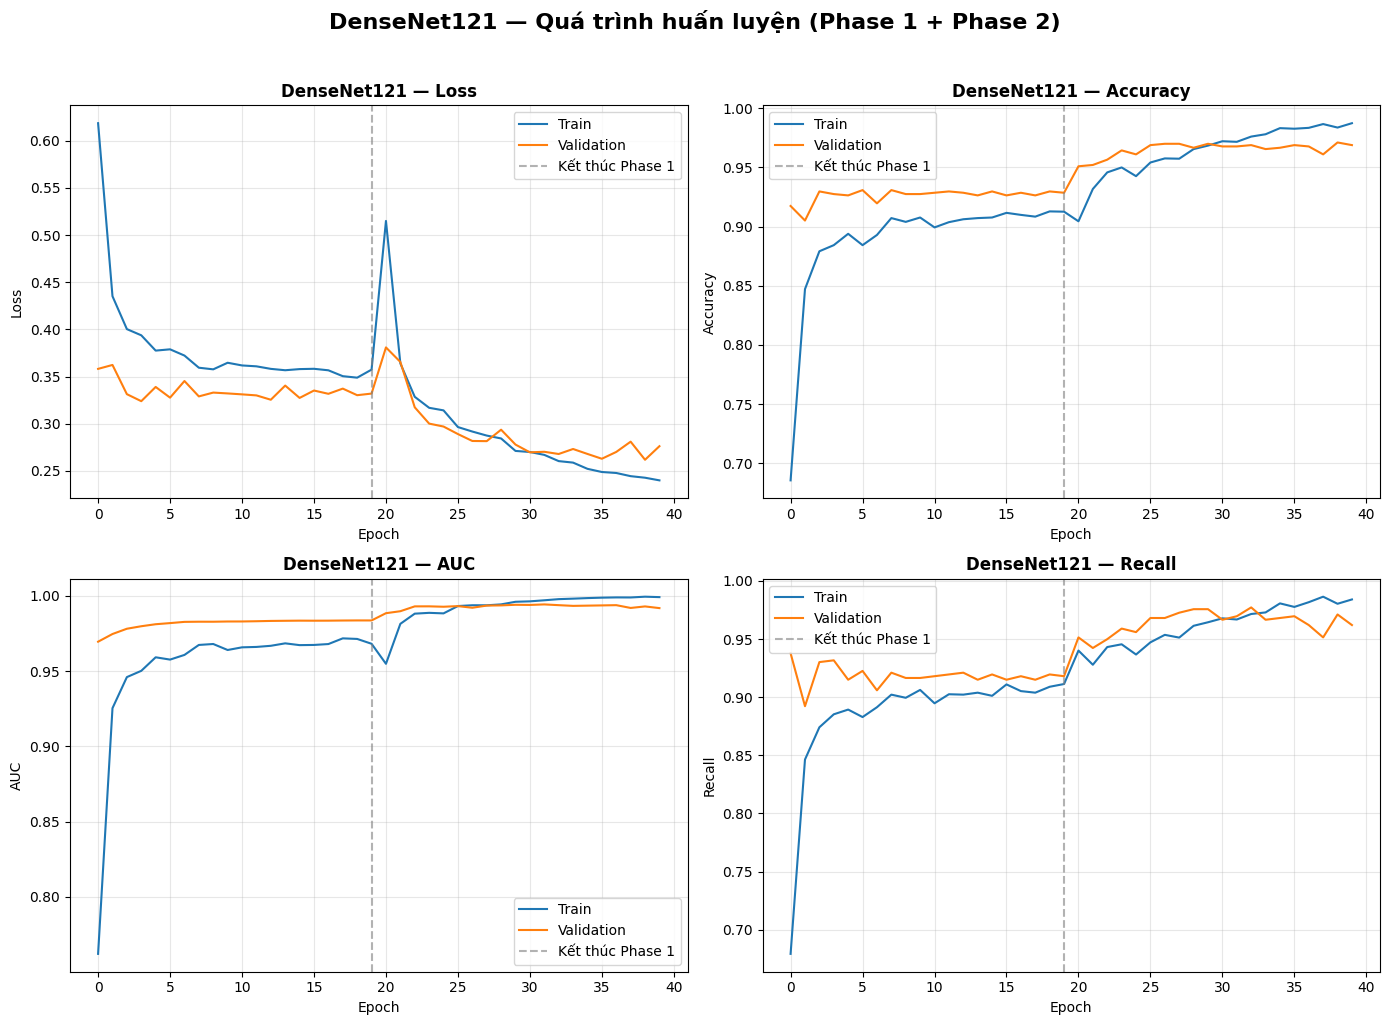

In [8]:
# ── Gộp lịch sử 2 phase thành 1 dict duy nhất để vẽ liền mạch ────────────────
hist = {}
for k in history_phase1.history.keys():
    hist[k] = history_phase1.history[k] + history_phase2.history[k]

n_phase1 = len(history_phase1.history["loss"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ("loss", "val_loss", "Loss"),
    ("accuracy", "val_accuracy", "Accuracy"),
    ("auc", "val_auc", "AUC"),
    ("recall", "val_recall", "Recall"),
]

for ax, (train_key, val_key, title) in zip(axes.flatten(), metrics_to_plot):
    ax.plot(hist[train_key], label="Train")
    ax.plot(hist[val_key], label="Validation")
    ax.axvline(x=n_phase1 - 1, color="gray", linestyle="--", alpha=0.6, label="Kết thúc Phase 1")
    ax.set_title(f"DenseNet121 — {title}", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("DenseNet121 — Quá trình huấn luyện (Phase 1 + Phase 2)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/results/densenet121_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Đánh giá trên tập Test

28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 737ms/step


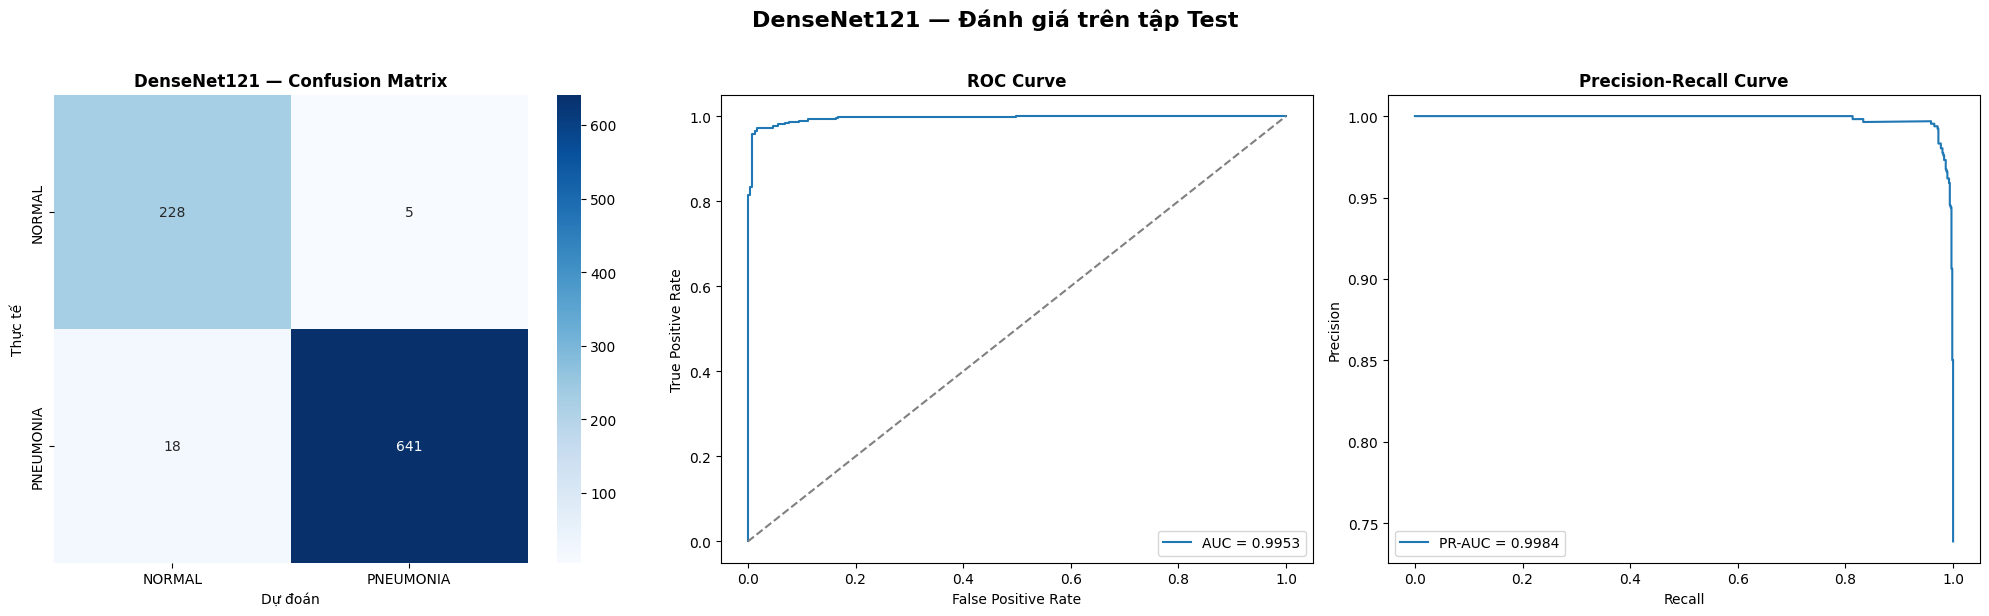

              precision    recall  f1-score   support

      NORMAL       0.93      0.98      0.95       233
   PNEUMONIA       0.99      0.97      0.98       659

    accuracy                           0.97       892
   macro avg       0.96      0.98      0.97       892
weighted avg       0.98      0.97      0.97       892

Specificity: 0.9785


In [9]:
# ── Dự đoán trên tập test ────────────────────────────────────────────────────
y_prob = model.predict(test_ds).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).flatten().astype(int)

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("DenseNet121 — Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Dự đoán")
axes[0].set_ylabel("Thực tế")

# ── ROC curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# ── Precision-Recall curve ──────────────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
axes[2].plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.4f}")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.suptitle("DenseNet121 — Đánh giá trên tập Test", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/results/densenet121_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"Specificity: {specificity:.4f}")

## 9. Trực quan hóa dự đoán trên ảnh test

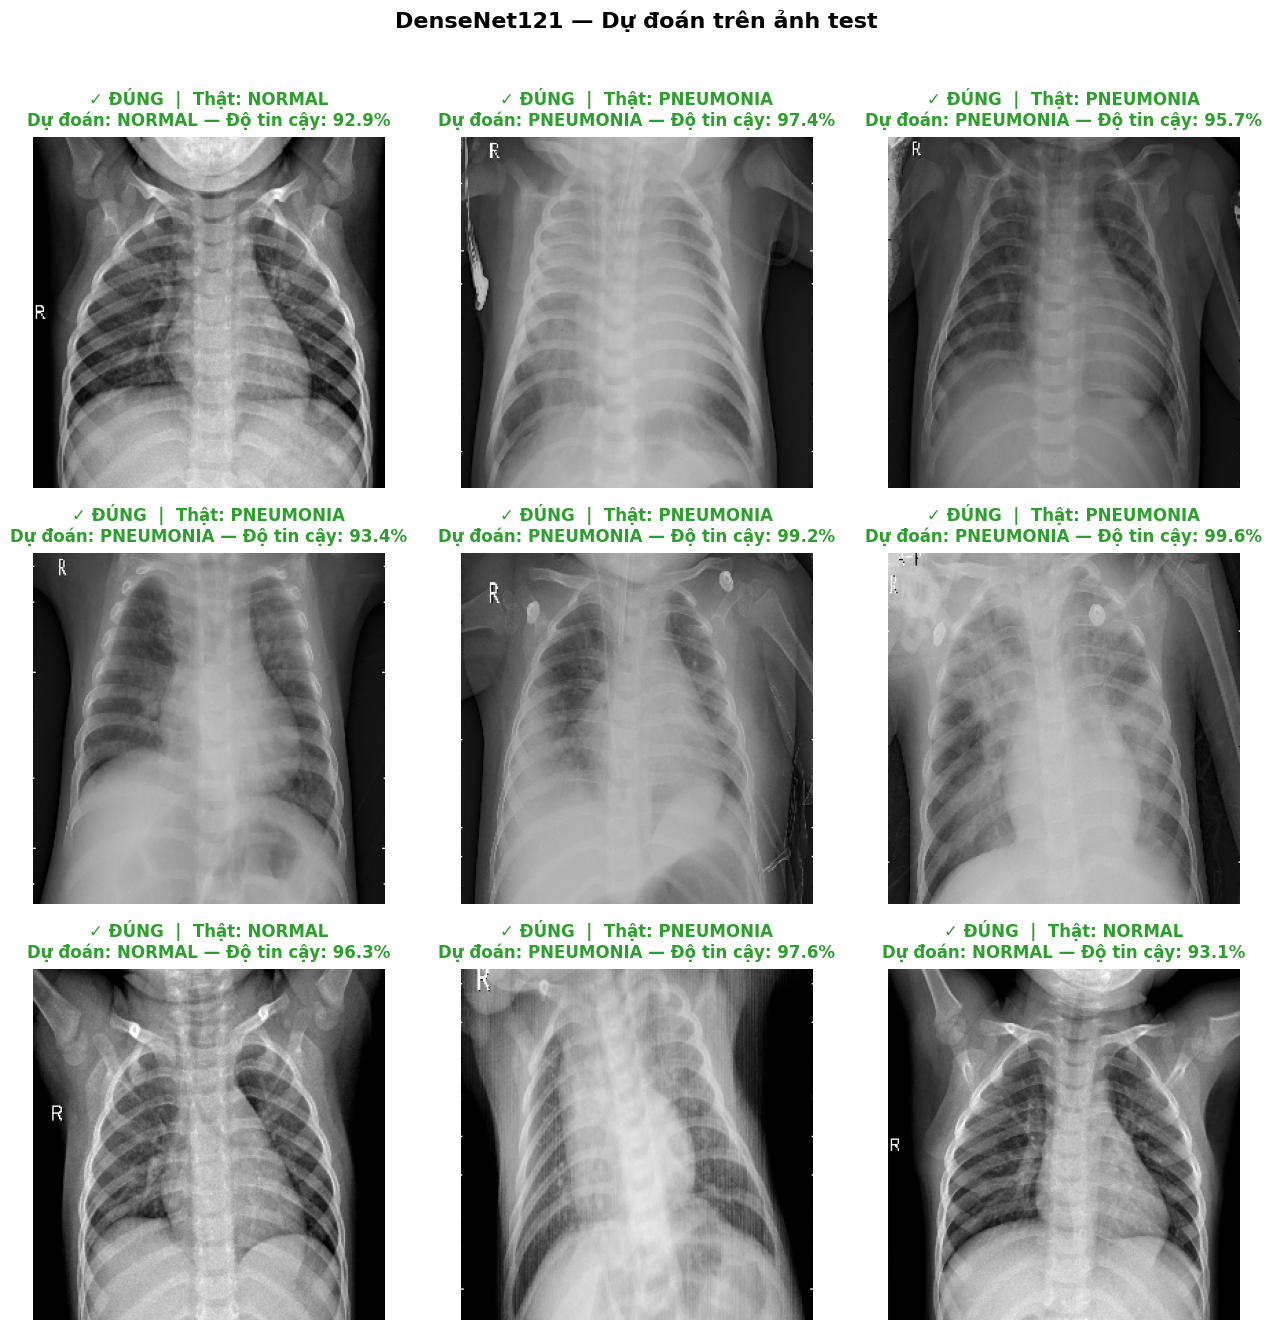

In [10]:
# ── Chọn ngẫu nhiên 9 ảnh test để xem trực quan kết quả dự đoán ─────────────
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(test_file_paths), size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    img_path = test_file_paths[idx]
    img = tf.keras.utils.load_img(img_path, target_size=(256, 256))

    true_label = "PNEUMONIA" if y_true[idx] == 1 else "NORMAL"
    pred_label = "PNEUMONIA" if y_pred[idx] == 1 else "NORMAL"
    confidence = y_prob[idx] if pred_label == "PNEUMONIA" else 1 - y_prob[idx]
    status = "✓ ĐÚNG" if true_label == pred_label else "✗ SAI"
    color = "#2ca02c" if true_label == pred_label else "#d62728"

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{status}  |  Thật: {true_label}\nDự đoán: {pred_label} — Độ tin cậy: {confidence*100:.1f}%",
        fontsize=12, fontweight="bold", color=color, pad=8
    )

plt.suptitle("DenseNet121 — Dự đoán trên ảnh test", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/results/densenet121_predictions_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Grad-CAM

/tmp/ipykernel_23/2160951824.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


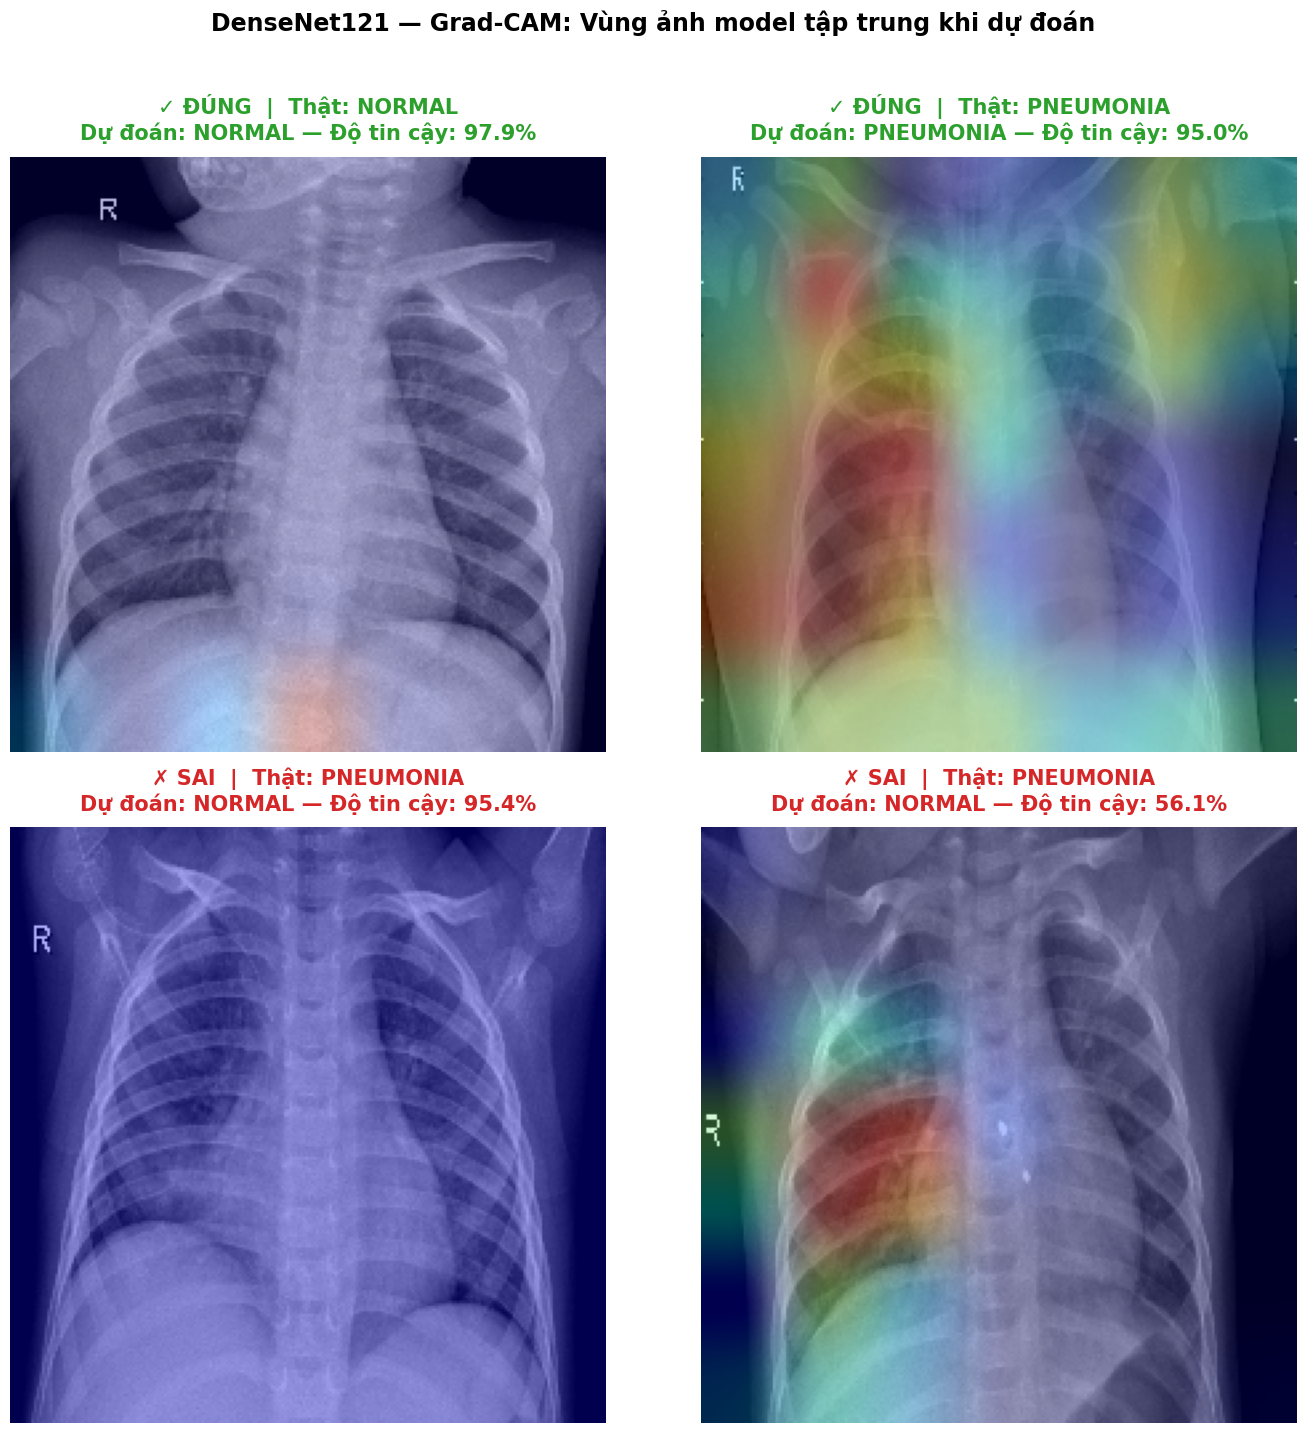

In [11]:
import matplotlib.cm as cm

def make_gradcam_heatmap_densenet(img_array, backbone, model):
    """Grad-CAM cho model dạng backbone lồng trong outer model (functional API)."""
    grad_model = tf.keras.Model(inputs=backbone.input, outputs=backbone.output)

    with tf.GradientTape() as tape:
        conv_output = grad_model(img_array)
        tape.watch(conv_output)
        gap_out = model.get_layer("gap")(conv_output)
        preds = model.get_layer("output")(gap_out)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()[0][0]


def overlay_gradcam(img_path, heatmap, alpha=0.45, img_size=(224, 224)):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img = tf.keras.utils.img_to_array(img)

    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + img
    return tf.keras.utils.array_to_img(superimposed)


# ── Chọn 4 ảnh: 2 đúng, 2 sai (nếu có đủ) ──────────────────────────────────
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx = np.where(y_pred != y_true)[0]

rng2 = np.random.default_rng(SEED)
pick_correct = rng2.choice(correct_idx, size=2, replace=False)
pick_wrong = rng2.choice(wrong_idx, size=min(2, len(wrong_idx)), replace=False)
gradcam_indices = np.concatenate([pick_correct, pick_wrong])

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, idx in zip(axes, gradcam_indices):
    img_path = test_file_paths[idx]

    raw_img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
    raw_arr = tf.keras.utils.img_to_array(raw_img)
    raw_arr = tf.image.resize_with_pad(raw_arr, IMG_SIZE[0], IMG_SIZE[1])
    raw_arr = raw_arr.numpy().copy()
    input_arr = densenet_preprocess(np.expand_dims(raw_arr, axis=0))

    heatmap, prob = make_gradcam_heatmap_densenet(input_arr, backbone, model)
    overlay_img = overlay_gradcam(img_path, heatmap, img_size=IMG_SIZE)

    true_label = "PNEUMONIA" if y_true[idx] == 1 else "NORMAL"
    pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    confidence = prob if pred_label == "PNEUMONIA" else 1 - prob
    status = "✓ ĐÚNG" if true_label == pred_label else "✗ SAI"
    color = "#2ca02c" if true_label == pred_label else "#d62728"

    ax.imshow(overlay_img)
    ax.axis("off")
    ax.set_title(
        f"{status}  |  Thật: {true_label}\nDự đoán: {pred_label} — Độ tin cậy: {confidence*100:.1f}%",
        fontsize=15, fontweight="bold", color=color, pad=12
    )

plt.suptitle("DenseNet121 — Grad-CAM: Vùng ảnh model tập trung khi dự đoán", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/results/densenet121_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Lưu model cuối

In [12]:
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

MODEL_NAME = "densenet121"
os.makedirs("/kaggle/working/results", exist_ok=True)

model.save(f"/kaggle/working/results/{MODEL_NAME}_final.keras")

summary = {
    "Model": MODEL_NAME,
    "Accuracy": round(accuracy_score(y_true, y_pred), 4),
    "Precision": round(precision_score(y_true, y_pred), 4),
    "Recall": round(recall_score(y_true, y_pred), 4),
    "Specificity": round(specificity, 4),
    "F1-score": round(f1_score(y_true, y_pred), 4),
    "ROC-AUC": round(roc_auc, 4),
    "PR-AUC": round(pr_auc, 4),
    "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
}
with open(f"/kaggle/working/results/{MODEL_NAME}_results.json", "w") as f:
    json.dump(summary, f, indent=2)

np.savez(f"/kaggle/working/results/{MODEL_NAME}_predictions.npz", y_true=y_true, y_prob=y_prob, y_pred=y_pred)

with open(f"/kaggle/working/results/{MODEL_NAME}_history.json", "w") as f:
    json.dump(hist, f, indent=2)

print(f"Đã lưu đầy đủ output cho {MODEL_NAME} tại /kaggle/working/results/")
for k, v in summary.items():
    print(f"  {k:<20}: {v}")

Đã lưu đầy đủ output cho densenet121 tại /kaggle/working/results/
  Model               : densenet121
  Accuracy            : 0.9742
  Precision           : 0.9923
  Recall              : 0.9727
  Specificity         : 0.9785
  F1-score            : 0.9824
  ROC-AUC             : 0.9953
  PR-AUC              : 0.9984
  TP                  : 641
  TN                  : 228
  FP                  : 5
  FN                  : 18
